In [2]:
import numpy as np
from matplotlib import pyplot as plt

In [3]:
from tqdm.notebook import tqdm

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset

In [5]:
# check if cuda is available
if torch.cuda.is_available():
    device = "cuda"
    torch.cuda.empty_cache()
else:
    device = "cpu"

In [6]:
# ToTensor: takes PIL image, converts to tensor and scales pixels to [0,1]
transform = transforms.Compose([transforms.ToTensor(),])

# Load the Fashion MNIST dataset
train_dataset = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST('./data', train=False, transform=transform)

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.63MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 165kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.20MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.6MB/s]


In [7]:
train_dataset[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [10]:
# original dataset used PIL images conveted online
# cache into single tensors for performance
xl = []
yl = []
for x, y in train_dataset:
    xl.append(x)
    yl.append(y)
X_train = torch.stack(xl)
y_train = torch.tensor(yl)
cached_train = TensorDataset(X_train, y_train)
xl = []
yl = []
for x, y in test_dataset:
    xl.append(x)
    yl.append(y)
X_test = torch.stack(xl)
y_test = torch.tensor(yl)
cached_test = TensorDataset(X_test, y_test)
del xl
del yl

In [11]:
labels=\
{0: "T-shirt/top",
 1: "Trouser",
 2: "Pullover",
 3: "Dress",
 4: "Coat",
 5: "Sandal",
 6: "Shirt",
 7: "Sneaker",
 8: "Bag",
 9: "Ankle boot"}

torch.float32
torch.Size([1, 28, 28])
tensor(9) Ankle boot


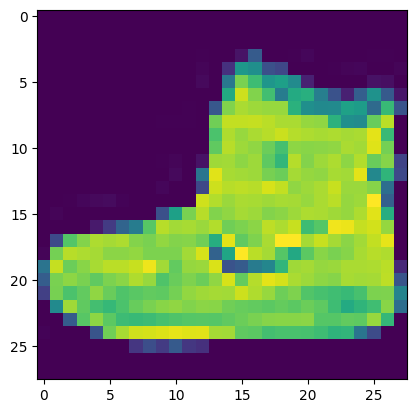

In [12]:
# drop-in replacement for MNIST
x, y = cached_train[0]
print(x.dtype)
print(x.shape)
plt.imshow(x.numpy().transpose(1,2,0))
print(y, labels[y.item()])

In [13]:
# batching, shuffling
train_dataloader = DataLoader(cached_train, batch_size=128, shuffle=True)
test_dataloader = DataLoader(cached_test, batch_size=128, shuffle=False)  # don't shuffle test set

In [20]:
# function to evaluate accuracy
def eval_net(net, d):
    net.eval()
    with torch.no_grad():
        acc_sum = 0
        n = 0
        for x, y in tqdm(d):
            pred = net(x.to(device))
            predicted = pred.argmax(axis=-1).cpu()
            acc_sum += (predicted==y).sum().item()
            n += x.shape[0]
    return acc_sum/n

In [21]:
# training loop
import torch.optim as optim

def fit(net, train=train_dataloader, valid=test_dataloader, epochs=5,
        learning_rate=None):
    net = net.to(device)

    if learning_rate is None:
        optimizer = optim.Adam(net.parameters())
    else:
        optimizer = optim.Adam(net.parameters(), lr=learning_rate)
    loss = torch.nn.CrossEntropyLoss()
    for e in range(epochs):
        net.train()
        for X, y in tqdm(train):
            optimizer.zero_grad()
            X = X.to(device)
            y = y.to(device)
            pred = net(X)
            l = loss(pred, y)
            l.backward()
            optimizer.step()
        if valid is not None:
            print("Accuracy at epoch", e, ":", eval_net(net, valid))

In [42]:
from torch.optim import SGD
from torch.optim import lr_scheduler
import copy
from torchsummary import summary # import the summary function here


In [27]:
# function to evaluate accuracy
def eval_net(net, d):
    net.eval()
    loss = torch.nn.CrossEntropyLoss(reduction="sum")
    with torch.no_grad():
        acc_sum = 0
        loss_sum = 0
        n = 0
        for x, y in d:
            y=y.to(device)
            x=x.to(device)
            pred = net(x)
            predicted = pred.argmax(axis=-1)
            acc_sum += (predicted==y).sum().item()
            loss_sum += loss(pred, y).item()
            n += x.shape[0]
    return acc_sum/n, loss_sum/n

In [45]:
def fit3(net, train=train_dataloader, valid=test_dataloader, epochs=50,
         patience=15,  # more patience on early stopping
         plateau_patience=3):
    net = net.to(device)

    optimizer = torch.optim.AdamW(net.parameters())
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer,
                                               patience=plateau_patience,
                                               mode="max",
                                               factor=0.1)

    summary(net, (1, 28, 28), device=device)


    loss = torch.nn.CrossEntropyLoss()
    hist_loss_train = []
    hist_loss_valid = []
    hist_acc_train = []
    hist_acc_valid = []

    best_val_acc = -float('inf')
    best_model = copy.deepcopy(net.state_dict())
    cur_patience = patience

    for e in range(epochs):
        net.train()
        for X, y in tqdm(train):
            optimizer.zero_grad()
            X = X.to(device)
            y = y.to(device)
            pred = net(X)
            l = loss(pred, y)
            l.backward()
            optimizer.step()
        acc_train, loss_train = eval_net(net, train)
        hist_loss_train.append(loss_train)
        hist_acc_train.append(acc_train)
        if valid is not None:
            acc_valid, loss_valid = eval_net(net, valid)
            hist_loss_valid.append(loss_valid)
            hist_acc_valid.append(acc_valid)
            print("Accuracy/loss at epoch", e, ":", acc_valid, loss_valid)
            # Early stopping
            if acc_valid > best_val_acc:
                # remember best model
                best_model = copy.deepcopy(net.state_dict())
                # reset early stopping
                best_val_acc = acc_valid
                cur_patience = patience
            else:
                cur_patience -= 1
                if cur_patience == 0:
                    print("Early stopping at epoch", e)
                    break
        if valid is not None:
            prev_lr = scheduler.get_last_lr()
            scheduler.step(acc_valid)
            if scheduler.get_last_lr() != prev_lr:
                print("Learning rate changed to", scheduler.get_last_lr())
    ret = {"loss": hist_loss_train, "accuracy": hist_acc_train}
    if valid is not None:
        ret["val_loss"] = hist_loss_valid
        ret["val_accuracy"] = hist_acc_valid
    # restore best model
    net.load_state_dict(best_model)
    return ret

In [46]:
def plot_history(hist):
    fig, ax = plt.subplots(ncols=2)
    ax[0].plot(hist['accuracy'], label="accuracy")
    if "val_accuracy" in hist:
        ax[0].plot(hist['val_accuracy'], label="val_accuracy")
    ax[1].plot(hist['loss'], label="loss")
    if "val_loss" in hist:
        ax[1].plot(hist['val_loss'], label="val_loss")
    fig.legend()

### Simple networks

In [47]:
m1 = torch.nn.Sequential(nn.Flatten(), nn.Linear(28*28, 10))
m1.to(device)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=10, bias=True)
)

In [56]:
hist = fit3(m1)
plot_history(hist)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                   [-1, 10]           7,850
Total params: 7,850
Trainable params: 7,850
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.03
Estimated Total Size (MB): 0.04
----------------------------------------------------------------


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 0 : 0.8395 0.46539841957092287


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 1 : 0.8395 0.4631584348678589


...

Accuracy/loss at epoch 12 : 0.8471 0.43859122252464294


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 13 : 0.8462 0.44166190156936647


  0%|          | 0/469 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
m1Wlasny = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3),
    nn.ReLU(),
    nn.Conv2d(32, 32, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(32, 32, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Dropout(0.25),
    nn.Linear(5*5*32, 128),
    nn.ReLU(),
    nn.Dropout(0.25),
    nn.Linear(128, 10),
  )

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 26, 26]             320
              ReLU-2           [-1, 32, 26, 26]               0
            Conv2d-3           [-1, 32, 24, 24]           9,248
              ReLU-4           [-1, 32, 24, 24]               0
         MaxPool2d-5           [-1, 32, 12, 12]               0
            Conv2d-6           [-1, 32, 10, 10]           9,248
              ReLU-7           [-1, 32, 10, 10]               0
         MaxPool2d-8             [-1, 32, 5, 5]               0
           Flatten-9                  [-1, 800]               0
          Dropout-10                  [-1, 800]               0
           Linear-11                  [-1, 128]         102,528
             ReLU-12                  [-1, 128]               0
          Dropout-13                  [-1, 128]               0
           Linear-14                   

  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 0 : 0.9238 0.22722939357757568


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 1 : 0.9245 0.21663701043128966


...

Accuracy/loss at epoch 42 : 0.9311 0.21791228682398797


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 43 : 0.9311 0.21791243579089642


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 44 : 0.9311 0.21791251299977302
Early stopping at epoch 44


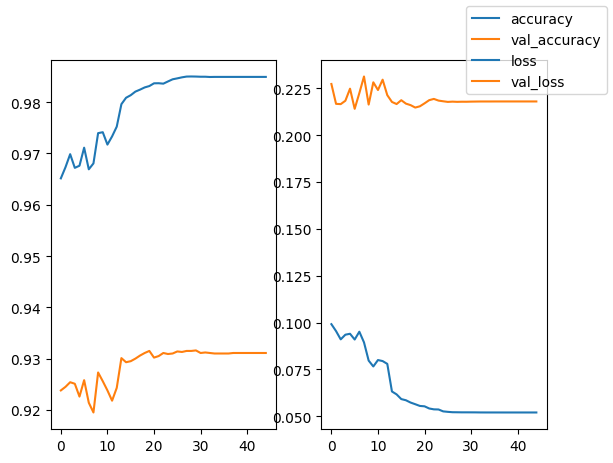

In [57]:
hist = fit3(m1Wlasny, epochs=100)
plot_history(hist)

In [52]:
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import v2

In [53]:
class mWlasny2(nn.Module):
    def __init__(self):
        super().__init__()
        self.c1 = nn.Conv2d(1, 32, kernel_size=3, padding="same")
        self.c2 = nn.Conv2d(32, 32, kernel_size=3, padding="same")

        self.fl = nn.Flatten()
        self.ll1 = nn.Linear(28*28*32, 10)



    def forward(self, x):
        if self.training:
          x = v2.Compose([
              v2.RandomAffine(10, translate=(0.05,0.05)),
              v2.GaussianBlur(kernel_size=3),
              v2.GaussianNoise(),
              v2.ToImage(),
              v2.ToDtype(torch.float32, scale=True),
              ])(x)
        c = self.c1(x)
        c = F.relu(c)
        c = self.c2(c)
        x = x + c
        x = F.relu(x)
        # x = F.max_pool2d(x, kernel_size=3)
        x = self.fl(x)
        # x = F.relu(c)
        x = F.dropout(x, p=0.25)
        x = self.ll1(x)
        return x


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
            Conv2d-2           [-1, 32, 28, 28]           9,248
           Flatten-3                [-1, 25088]               0
            Linear-4                   [-1, 10]         250,890
Total params: 260,458
Trainable params: 260,458
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.57
Params size (MB): 0.99
Estimated Total Size (MB): 1.57
----------------------------------------------------------------


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 0 : 0.803 0.5353008279323578


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 1 : 0.8323 0.4698444692850113


...

Accuracy/loss at epoch 37 : 0.89 0.3300569093227386


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 38 : 0.8887 0.32673822379112244


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 39 : 0.8897 0.3259623388528824
Early stopping at epoch 39


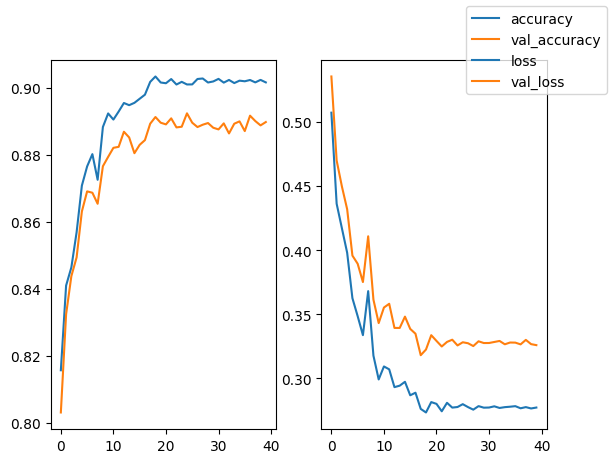

In [54]:
net = mWlasny2()
hist = fit3(net)
plot_history(hist)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 128]         100,480
              ReLU-3                  [-1, 128]               0
            Linear-4                   [-1, 10]           1,290
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.39
Estimated Total Size (MB): 0.40
----------------------------------------------------------------


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 0 : 0.8306 0.47811044268608094


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 1 : 0.8463 0.44009047808647156


...

Accuracy/loss at epoch 42 : 0.89 0.3169630005598068


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 43 : 0.89 0.31696251394748687


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 44 : 0.89 0.3169627070188522
Early stopping at epoch 44


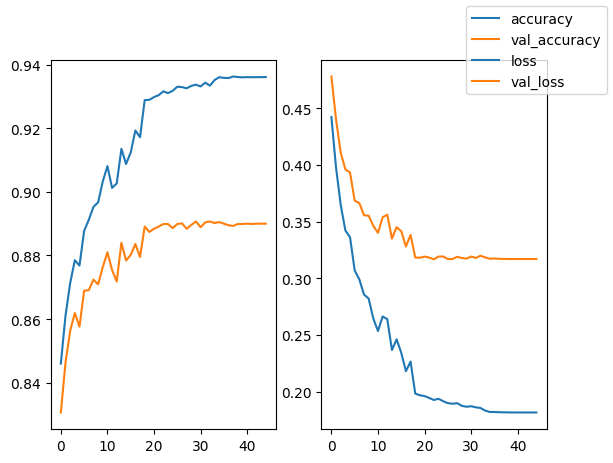

In [55]:
m2 = nn.Sequential(nn.Flatten(), nn.Linear(28*28, 128), nn.ReLU(), nn.Linear(128, 10))
m2.to(device)
history = fit3(m2)
plot_history(hist=history)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 128]         100,480
              ReLU-3                  [-1, 128]               0
            Linear-4                  [-1, 128]          16,512
              ReLU-5                  [-1, 128]               0
            Linear-6                   [-1, 10]           1,290
Total params: 118,282
Trainable params: 118,282
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.45
Estimated Total Size (MB): 0.46
----------------------------------------------------------------


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 0 : 0.8349 0.46209982080459594


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 1 : 0.8509 0.42393817834854125


...

Accuracy/loss at epoch 40 : 0.8961 0.3370122253865004


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 41 : 0.8961 0.33701601217389104


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 42 : 0.8961 0.33701662224531176
Early stopping at epoch 42


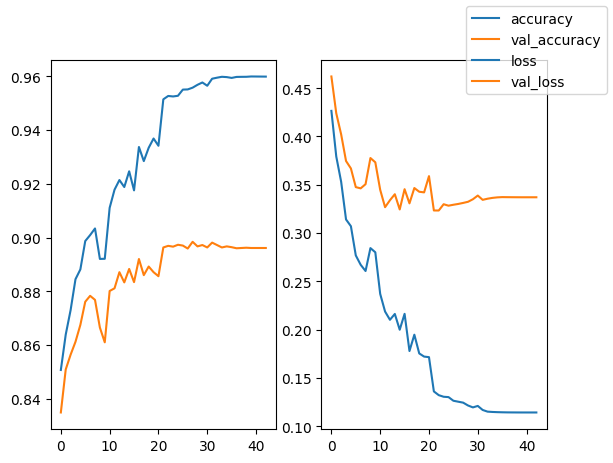

In [58]:
m3 = nn.Sequential(nn.Flatten(), nn.Linear(28*28, 128), nn.ReLU(), nn.Linear(128, 128), nn.ReLU(), nn.Linear(128, 10))
history = fit3(m3)
plot_history(hist=history)

### Dropout / batch normalization

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 128]         100,480
              ReLU-3                  [-1, 128]               0
            Linear-4                  [-1, 128]          16,512
              ReLU-5                  [-1, 128]               0
            Linear-6                   [-1, 10]           1,290
Total params: 118,282
Trainable params: 118,282
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.45
Estimated Total Size (MB): 0.46
----------------------------------------------------------------


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 0 : 0.8937 0.34216684547662735


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 1 : 0.8897 0.3547046792984009


...

Accuracy/loss at epoch 21 : 0.8991 0.3636353915929794


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 22 : 0.899 0.36363855016976593


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 23 : 0.8991 0.36364093901365996
Early stopping at epoch 23


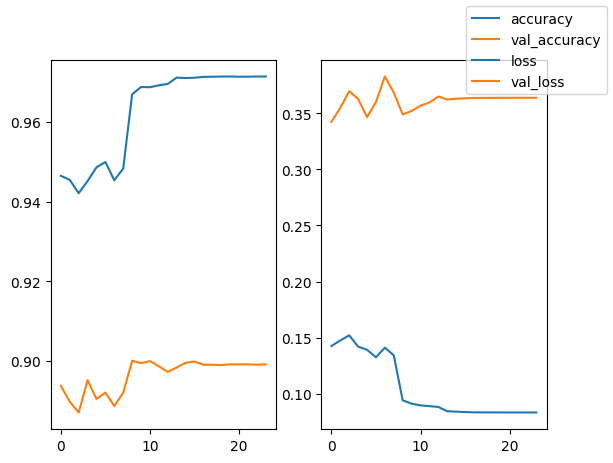

In [59]:
m4 = nn.Sequential(nn.Flatten(),
                   nn.Linear(28*28, 128), nn.ReLU(),
                   nn.Dropout(0.25),
                   nn.Linear(128, 128), nn.ReLU(),
                   nn.Dropout(0.25),
                   nn.Linear(128, 10),
)
history = fit3(m3)
plot_history(hist=history)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 128]         100,480
              ReLU-3                  [-1, 128]               0
       BatchNorm1d-4                  [-1, 128]             256
            Linear-5                  [-1, 128]          16,512
              ReLU-6                  [-1, 128]               0
       BatchNorm1d-7                  [-1, 128]             256
            Linear-8                   [-1, 10]           1,290
Total params: 118,794
Trainable params: 118,794
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.45
Estimated Total Size (MB): 0.47
----------------------------------------------------------------


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 0 : 0.8364 0.44192442729473114


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 1 : 0.8634 0.38953570771217344


...

Accuracy/loss at epoch 34 : 0.8988 0.31380534865260123


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 35 : 0.8996 0.3130211973845959


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 36 : 0.8987 0.31437643539905546
Early stopping at epoch 36


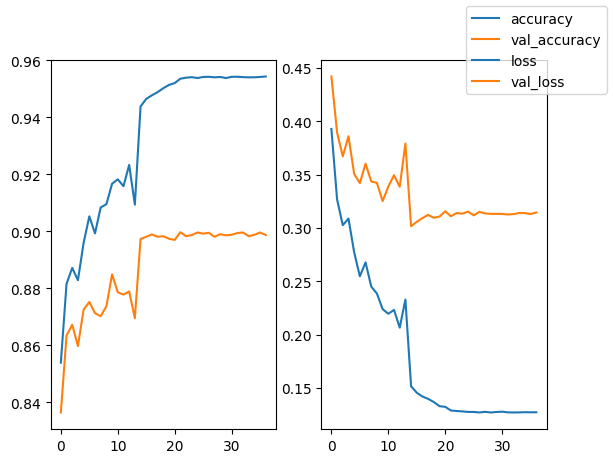

In [60]:
m5 = nn.Sequential(nn.Flatten(),
                   nn.Linear(28*28, 128), nn.ReLU(),
                   nn.BatchNorm1d(128),
                   nn.Linear(128, 128), nn.ReLU(),
                   nn.BatchNorm1d(128),
                   nn.Linear(128, 10),
)
history = fit3(m5)
plot_history(hist=history)

### Convolutional layers

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 26, 26]             320
              ReLU-2           [-1, 32, 26, 26]               0
           Flatten-3                [-1, 21632]               0
            Linear-4                   [-1, 10]         216,330
Total params: 216,650
Trainable params: 216,650
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.50
Params size (MB): 0.83
Estimated Total Size (MB): 1.32
----------------------------------------------------------------


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 0 : 0.8698 0.36900113673210144


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 1 : 0.8773 0.3430110046386719


...

Accuracy/loss at epoch 47 : 0.9115 0.32760659809112547


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 48 : 0.9113 0.32764128828048705


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 49 : 0.9114 0.32765145692825315
Learning rate changed to [1.0000000000000002e-07]


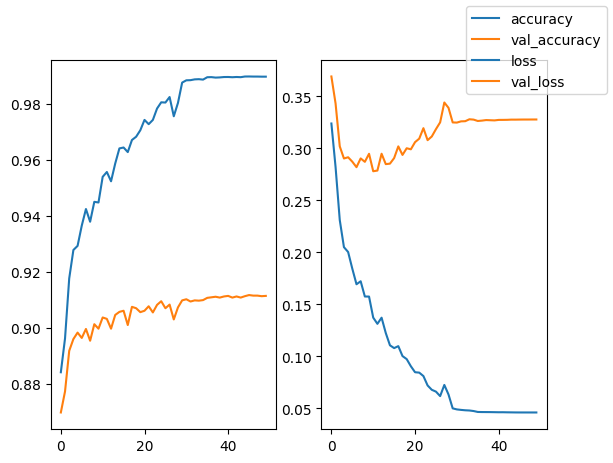

In [61]:
m6 = nn.Sequential(nn.Conv2d(1, 32, 3), nn.ReLU(),
                   nn.Flatten(),
                   nn.Linear(32*26*26, 10),
)
history = fit3(m6)
plot_history(hist=history)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 26, 26]             320
              ReLU-2           [-1, 32, 26, 26]               0
            Conv2d-3           [-1, 32, 24, 24]           9,248
              ReLU-4           [-1, 32, 24, 24]               0
           Flatten-5                [-1, 18432]               0
            Linear-6                   [-1, 10]         184,330
Total params: 193,898
Trainable params: 193,898
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.75
Params size (MB): 0.74
Estimated Total Size (MB): 1.49
----------------------------------------------------------------


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 0 : 0.8723 0.36356988320350647


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 1 : 0.8898 0.30517499113082885


...

Accuracy/loss at epoch 27 : 0.9097 0.33525743703842165


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 28 : 0.9097 0.33526636085510253


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 29 : 0.9097 0.33527287483215334
Early stopping at epoch 29


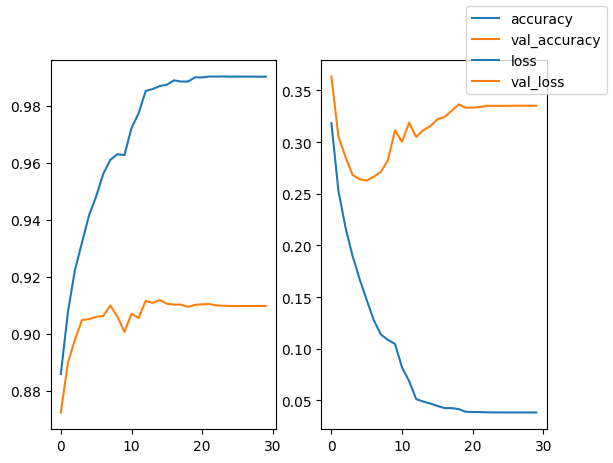

In [62]:
m7 = nn.Sequential(nn.Conv2d(1, 32, 3), nn.ReLU(),
                   nn.Conv2d(32, 32, 3), nn.ReLU(),
                   nn.Flatten(),
                   nn.Linear(32*24*24, 10),
)
history = fit3(m7)
plot_history(hist=history)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 26, 26]             640
              ReLU-2           [-1, 64, 26, 26]               0
            Conv2d-3           [-1, 64, 24, 24]          36,928
              ReLU-4           [-1, 64, 24, 24]               0
         MaxPool2d-5           [-1, 64, 12, 12]               0
            Conv2d-6          [-1, 256, 10, 10]         147,712
              ReLU-7          [-1, 256, 10, 10]               0
         MaxPool2d-8            [-1, 256, 5, 5]               0
           Flatten-9                 [-1, 6400]               0
           Linear-10                  [-1, 128]         819,328
             ReLU-11                  [-1, 128]               0
           Linear-12                   [-1, 10]           1,290
Total params: 1,005,898
Trainable params: 1,005,898
Non-trainable params: 0
---------------------------

  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 0 : 0.867 0.3703202697753906


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 1 : 0.8955 0.29166399405002597


...

Accuracy/loss at epoch 31 : 0.9305 0.4764284542798996


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 32 : 0.9305 0.4765096759557724


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 33 : 0.9305 0.47659727135896685
Early stopping at epoch 33


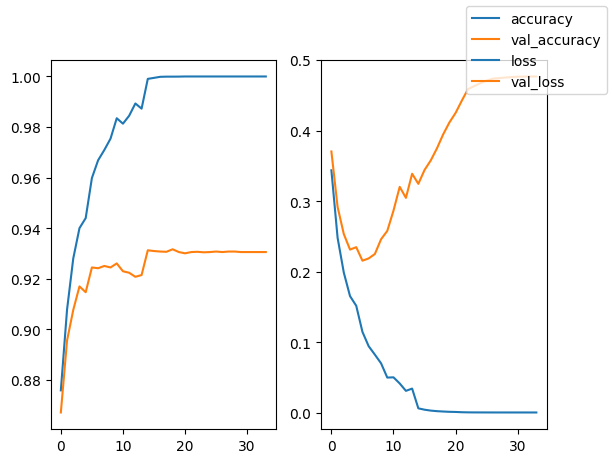

In [63]:
m8 = nn.Sequential(nn.Conv2d(1, 64, 3), nn.ReLU(),
                   nn.Conv2d(64, 64, 3), nn.ReLU(),
                   nn.MaxPool2d(2),
                   nn.Conv2d(64, 256, 3), nn.ReLU(),
                   nn.MaxPool2d(2),
                   nn.Flatten(),
                   nn.Linear(256*5*5, 128), nn.ReLU(),
                   nn.Linear(128, 10),
)
history = fit3(m8)
plot_history(hist=history)
#fit(m8, epochs=50, learning_rate=0.0001)

### Residual blocks

In [66]:
class ResidBlock(nn.Module):
    def __init__(self, first=False):
        super().__init__()
        if first:
            self.c1 = nn.Conv2d(1, 32, 3, padding="same")
            self.c2 = nn.Conv2d(32, 32, 3, padding="same")
        else:
            self.c1 = nn.Conv2d(32, 32, 3, padding="same")
            self.c2 = nn.Conv2d(32, 32, 3, padding="same")
    def forward(self, x):
        c = self.c1(x)
        c = F.relu(c)
        c = self.c2(c)
        return F.relu(x + c)

In [67]:
layers = [ResidBlock(True)] + [ResidBlock() for i in range(9)]
layers.append(nn.Flatten())
layers.append(nn.Linear(32*28*28, 10))
m9 = nn.Sequential(*layers)
history = fit3(m9)
plot_history(hist=history)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
            Conv2d-2           [-1, 32, 28, 28]           9,248
        ResidBlock-3           [-1, 32, 28, 28]               0
            Conv2d-4           [-1, 32, 28, 28]           9,248
            Conv2d-5           [-1, 32, 28, 28]           9,248
        ResidBlock-6           [-1, 32, 28, 28]               0
            Conv2d-7           [-1, 32, 28, 28]           9,248
            Conv2d-8           [-1, 32, 28, 28]           9,248
        ResidBlock-9           [-1, 32, 28, 28]               0
           Conv2d-10           [-1, 32, 28, 28]           9,248
           Conv2d-11           [-1, 32, 28, 28]           9,248
       ResidBlock-12           [-1, 32, 28, 28]               0
           Conv2d-13           [-1, 32, 28, 28]           9,248
           Conv2d-14           [-1, 32,

  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 0 : 0.8827 0.32576066148281096


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 1 : 0.9001 0.2827557088136673


...

Accuracy/loss at epoch 9 : 0.9191 0.3952110056877136


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 10 : 0.9166 0.4635200675010681


  0%|          | 0/469 [00:00<?, ?it/s]

KeyboardInterrupt: 

# Augmentation

In [68]:
from torchvision.transforms import v2

In [69]:
# define a separate transformation block
# reason: torchvision transforms do not implement eval() properly
class TransformBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.transform = v2.Compose([
            v2.RandomHorizontalFlip(0.5),
            v2.RandomAffine(10, translate=(0.1,0.1)),
            v2.GaussianNoise(0.1)
            ])
    def forward(self, x):
        if self.training:
            return self.transform(x)
        else:
            return x

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Compose-1            [-1, 1, 28, 28]               0
    TransformBlock-2            [-1, 1, 28, 28]               0
            Conv2d-3           [-1, 32, 26, 26]             320
              ReLU-4           [-1, 32, 26, 26]               0
            Conv2d-5           [-1, 32, 24, 24]           9,248
              ReLU-6           [-1, 32, 24, 24]               0
           Flatten-7                [-1, 18432]               0
            Linear-8                   [-1, 10]         184,330
Total params: 193,898
Trainable params: 193,898
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.76
Params size (MB): 0.74
Estimated Total Size (MB): 1.51
----------------------------------------------------------------


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 0 : 0.724 0.8270931357383728


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 1 : 0.7997 0.5924922332763672


...

Accuracy/loss at epoch 23 : 0.8287 0.5188018605232239


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 24 : 0.8282 0.520269993019104


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy/loss at epoch 25 : 0.8284 0.5208124901771546
Early stopping at epoch 25


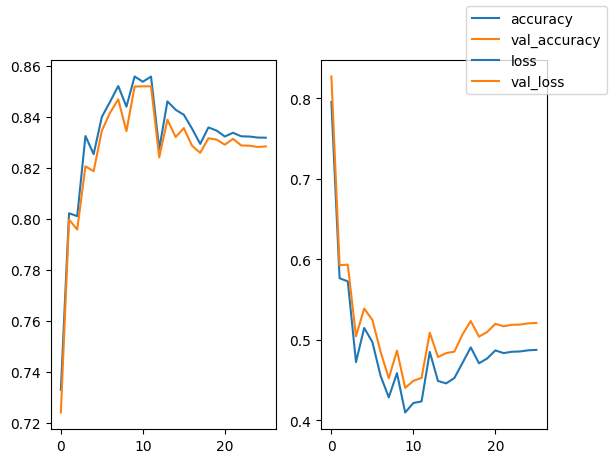

In [70]:
m10 = nn.Sequential(
    TransformBlock(),
    nn.Conv2d(1, 32, 3), nn.ReLU(),
    nn.Conv2d(32, 32, 3), nn.ReLU(),
    nn.Flatten(),
    nn.Linear(32*24*24, 10),
)
history = fit3(m10)
plot_history(hist=history)

# Interpretability / diagnostics

### training stability


In [71]:
import matplotlib.pyplot as plt

In [72]:
def eval_net_w_loss(net, d):
    net.eval()
    loss = torch.nn.CrossEntropyLoss(reduction="sum")
    with torch.no_grad():
        acc_sum = 0
        loss_sum = 0
        n = 0
        for x, y in d:
            y=y.to(device)
            x=x.to(device)
            pred = net(x)
            predicted = pred.argmax(axis=-1)
            acc_sum += (predicted==y).sum().item()
            loss_sum += loss(pred, y).item()
            n += x.shape[0]
    return acc_sum/n, loss_sum/n

In [73]:
# the fit function which tracks history
def fit_w_history(net, train=train_dataloader, valid=test_dataloader, epochs=5,
                learning_rate=None):
    net = net.to(device)

    if learning_rate is None:
        optimizer = optim.Adam(net.parameters())
    else:
        optimizer = optim.Adam(net.parameters(), lr=learning_rate)
    loss = torch.nn.CrossEntropyLoss()
    hist_loss_train = []
    hist_loss_valid = []
    hist_acc_train = []
    hist_acc_valid = []
    for e in tqdm(range(epochs)):
        net.train()
        for X, y in train:
            optimizer.zero_grad()
            X = X.to(device)
            y = y.to(device)
            pred = net(X)
            l = loss(pred, y)
            l.backward()
            optimizer.step()
        acc_train, loss_train = eval_net_w_loss(net, train)
        acc_valid, loss_valid = eval_net_w_loss(net, valid)
        hist_loss_train.append(loss_train)
        hist_loss_valid.append(loss_valid)
        hist_acc_train.append(acc_train)
        hist_acc_valid.append(acc_valid)
        if valid is not None:
            print("Accuracy/loss at epoch", e, ":", acc_valid, loss_valid)
    ret = {"loss": hist_loss_train, "val_loss": hist_loss_valid,
           "accuracy": hist_acc_train, "val_accuracy": hist_acc_valid}
    return ret

In [74]:
m = nn.Sequential(
    #TransformBlock(),
    nn.Conv2d(1, 32, 3), nn.ReLU(),
    nn.Conv2d(32, 32, 3), nn.ReLU(),
    nn.Flatten(),
    nn.Linear(32*24*24, 10),
)
hist = fit_w_history(m, epochs=30, learning_rate=0.001)

  0%|          | 0/30 [00:00<?, ?it/s]

Accuracy/loss at epoch 0 : 0.8784 0.3466389681339264
Accuracy/loss at epoch 1 : 0.9 0.29038810691833494
Accuracy/loss at epoch 2 : 0.9009 0.2799650871992111
Accuracy/loss at epoch 3 : 0.9024 0.27628947303295137
Accuracy/loss at epoch 4 : 0.9086 0.2608063508033752
Accuracy/loss at epoch 5 : 0.9077 0.27177988634109496
Accuracy/loss at epoch 6 : 0.9087 0.26898970303535463
Accuracy/loss at epoch 7 : 0.907 0.2934643342494965
Accuracy/loss at epoch 8 : 0.9122 0.2784976858615875
Accuracy/loss at epoch 9 : 0.9124 0.28750503885746004
Accuracy/loss at epoch 10 : 0.9104 0.2998691354751587
Accuracy/loss at epoch 11 : 0.9069 0.3248703631639481
Accuracy/loss at epoch 12 : 0.9117 0.3466264294743538
Accuracy/loss at epoch 13 : 0.9029 0.3772455961227417
Accuracy/loss at epoch 14 : 0.9059 0.38748724069595336
Accuracy/loss at epoch 15 : 0.899 0.41076573861837384
Accuracy/loss at epoch 16 : 0.9084 0.4237651755332947
Accuracy/loss at epoch 17 : 0.905 0.4558209671020508
Accuracy/loss at epoch 18 : 0.9037 0.

In [ ]:
hist

{'loss': [0.31570383717219036,
  0.2685313114643097,
  0.2308518931865692,
  0.1910774882634481,
  0.17040077525774638,
  0.15004461126327515,
  0.14262427598635355,
  0.12260044128894806,
  0.11106007776260376,
  0.0859385007182757,
  0.07960606427987417,
  0.06911075098911922,
  0.06489540777603785,
  0.056933733942111334,
  0.04829609666268031,
  0.046490768516063694,
  0.03968538424770037,
  0.035223502645889915,
  0.03376775586009025,
  0.027274556826551756,
  0.021731366746127606,
  0.026923907920718193,
  0.02056532795826594,
  0.015536878042916457,
  0.016248465769241254,
  0.015142895490676165,
  0.015028077466785908,
  0.01102214372418821,
  0.012017139402776957,
  0.0171485759280622],
 'val_loss': [0.351247629070282,
  0.32131598405838013,
  0.2951062664985657,
  0.2740765313386917,
  0.2673478058338165,
  0.26802033624649046,
  0.2862357283592224,
  0.27869118418693545,
  0.2900166139602661,
  0.2851055820941925,
  0.32030175075531003,
  0.31387546882629397,
  0.34023947982

In [ ]:
hist["accuracy"]

[0.8872666666666666,
 0.9043166666666667,
 0.9174333333333333,
 0.93335,
 0.9400666666666667,
 0.9466833333333333,
 0.9475666666666667,
 0.9562,
 0.9600333333333333,
 0.9720166666666666,
 0.9724833333333334,
 0.9773333333333334,
 0.97905,
 0.9812166666666666,
 0.9839,
 0.9837333333333333,
 0.9878666666666667,
 0.9887,
 0.9884166666666667,
 0.9911333333333333,
 0.9938166666666667,
 0.99095,
 0.9938,
 0.9958833333333333,
 0.9949666666666667,
 0.99555,
 0.99545,
 0.99725,
 0.9966,
 0.9940833333333333]

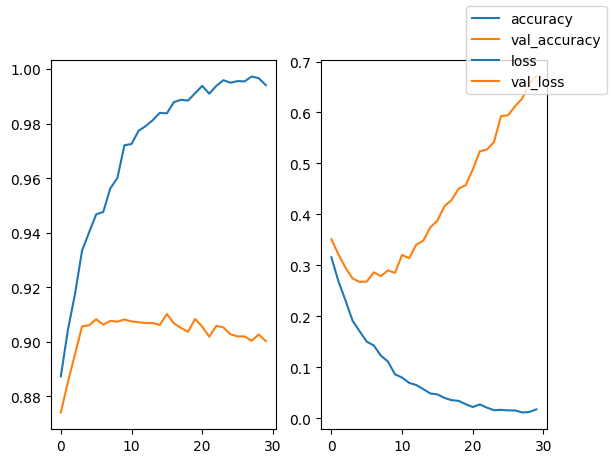

In [ ]:
fig, ax = plt.subplots(ncols=2)
ax[0].plot(hist['accuracy'], label="accuracy")
ax[0].plot(hist['val_accuracy'], label="val_accuracy")
ax[1].plot(hist['loss'], label="loss")
ax[1].plot(hist['val_loss'], label="val_loss")
fig.legend()

### model improvement: generic methods

In [ ]:
# wider convolutions
# residual connections
# early stopping
# training step adaptation

  0%|          | 0/50 [00:00<?, ?it/s]

Accuracy/loss at epoch 0 : 0.1 2.30288618812561
Accuracy/loss at epoch 1 : 0.1 2.302773514556885
Accuracy/loss at epoch 2 : 0.1 2.302731328201294
Accuracy/loss at epoch 3 : 0.1 2.302801651000977
Accuracy/loss at epoch 4 : 0.1 2.302913133239746
Accuracy/loss at epoch 5 : 0.1 2.303021427154541
Accuracy/loss at epoch 6 : 0.1 2.303521830368042
Accuracy/loss at epoch 7 : 0.1 2.303329295349121
Accuracy/loss at epoch 8 : 0.1 2.3032905681610107
Accuracy/loss at epoch 9 : 0.1 2.303127623748779
Accuracy/loss at epoch 10 : 0.1 2.3029165138244627
Accuracy/loss at epoch 11 : 0.1 2.3032005126953123
Accuracy/loss at epoch 12 : 0.1 2.303636254119873
Accuracy/loss at epoch 13 : 0.1 2.3030011867523195
Accuracy/loss at epoch 14 : 0.1 2.3029132278442384
Accuracy/loss at epoch 15 : 0.1 2.3029073337554933
Accuracy/loss at epoch 16 : 0.1 2.303313310241699
Accuracy/loss at epoch 17 : 0.1 2.30298109664917
Accuracy/loss at epoch 18 : 0.1 2.302955667114258
Accuracy/loss at epoch 19 : 0.1 2.3034498371124266
Accur

  0%|          | 0/50 [00:00<?, ?it/s]

Accuracy/loss at epoch 0 : 0.861 0.3948157974243164
Accuracy/loss at epoch 1 : 0.8893 0.30957254371643067
Accuracy/loss at epoch 2 : 0.899 0.28311979603767395
Accuracy/loss at epoch 3 : 0.9003 0.2759683143138886
Accuracy/loss at epoch 4 : 0.9 0.2811748235702515
Accuracy/loss at epoch 5 : 0.9116 0.2619312547683716
Accuracy/loss at epoch 6 : 0.9103 0.27058577156066893
Accuracy/loss at epoch 7 : 0.9141 0.2631831467151642
Accuracy/loss at epoch 8 : 0.9097 0.27965156307220457
Accuracy/loss at epoch 9 : 0.9114 0.2941260619163513
Accuracy/loss at epoch 10 : 0.9128 0.290268989944458
Accuracy/loss at epoch 11 : 0.9094 0.3048895734786987
Accuracy/loss at epoch 12 : 0.9103 0.31308049392700193
Accuracy/loss at epoch 13 : 0.91 0.32779126968383787
Accuracy/loss at epoch 14 : 0.9056 0.3765836359024048
Accuracy/loss at epoch 15 : 0.9095 0.37734349021911623
Accuracy/loss at epoch 16 : 0.906 0.38954573955535887
Accuracy/loss at epoch 17 : 0.9047 0.4113247510910034
Accuracy/loss at epoch 18 : 0.9073 0.42

  0%|          | 0/50 [00:00<?, ?it/s]

Accuracy/loss at epoch 0 : 0.8209 0.5034439715862274
Accuracy/loss at epoch 1 : 0.8422 0.441439781332016
Accuracy/loss at epoch 2 : 0.8563 0.4082474092006683
Accuracy/loss at epoch 3 : 0.8658 0.3830319818496704
Accuracy/loss at epoch 4 : 0.8702 0.3702382113456726
Accuracy/loss at epoch 5 : 0.8776 0.34755676608085634
Accuracy/loss at epoch 6 : 0.8829 0.3364848136425018
Accuracy/loss at epoch 7 : 0.8838 0.33332381646633147
Accuracy/loss at epoch 8 : 0.887 0.32615834732055665
Accuracy/loss at epoch 9 : 0.8874 0.32111367211341857
Accuracy/loss at epoch 10 : 0.8907 0.31352798800468445
Accuracy/loss at epoch 11 : 0.8915 0.3100614908695221
Accuracy/loss at epoch 12 : 0.8884 0.3087728130340576
Accuracy/loss at epoch 13 : 0.8924 0.3063914373397827
Accuracy/loss at epoch 14 : 0.893 0.3012140651464462
Accuracy/loss at epoch 15 : 0.895 0.2964611105442047
Accuracy/loss at epoch 16 : 0.8959 0.2954886271953583
Accuracy/loss at epoch 17 : 0.8991 0.2908991869926453
Accuracy/loss at epoch 18 : 0.8978 0.

  0%|          | 0/50 [00:00<?, ?it/s]

Accuracy/loss at epoch 0 : 0.7198 0.886901716041565
Accuracy/loss at epoch 1 : 0.7541 0.6876737244606018
Accuracy/loss at epoch 2 : 0.7747 0.6198339473247528
Accuracy/loss at epoch 3 : 0.7915 0.5771832828044892
Accuracy/loss at epoch 4 : 0.7976 0.5489272912979126
Accuracy/loss at epoch 5 : 0.8089 0.5274358551979065
Accuracy/loss at epoch 6 : 0.8161 0.511491959476471
Accuracy/loss at epoch 7 : 0.8218 0.49870515308380126
Accuracy/loss at epoch 8 : 0.8242 0.48902896518707273
Accuracy/loss at epoch 9 : 0.8253 0.479733220911026
Accuracy/loss at epoch 10 : 0.8296 0.47193052711486816
Accuracy/loss at epoch 11 : 0.8342 0.4629430229663849
Accuracy/loss at epoch 12 : 0.8354 0.4567028085708618
Accuracy/loss at epoch 13 : 0.8384 0.45008253049850466
Accuracy/loss at epoch 14 : 0.8392 0.44670877895355227
Accuracy/loss at epoch 15 : 0.8445 0.43982784676551817
Accuracy/loss at epoch 16 : 0.844 0.4349592108249664
Accuracy/loss at epoch 17 : 0.8473 0.43095364813804626
Accuracy/loss at epoch 18 : 0.8474 

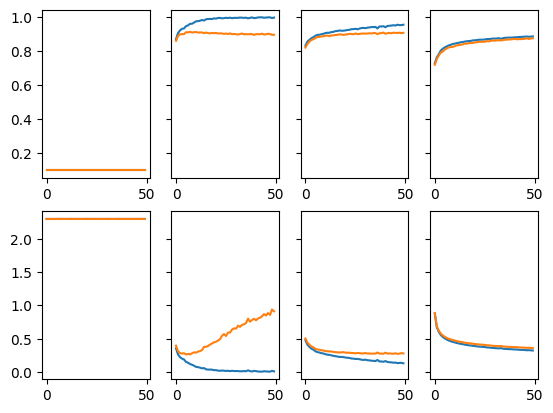

In [ ]:
fig, ax = plt.subplots(ncols=4, nrows=2, sharey="row")
for i, learning_rate in enumerate([1e-2, 1e-3, 1e-4, 1e-5]):
    # recreate model to reinitialize weights
    m = nn.Sequential(
        nn.Conv2d(1, 32, 3), nn.ReLU(),
        nn.Conv2d(32, 32, 3), nn.ReLU(),
        nn.Flatten(),
        nn.Linear(32*24*24, 10),
    )
    hist = fit_w_history(m, epochs=50, learning_rate=learning_rate)
    ax[0,i].plot(hist['accuracy'], label="accuracy")
    ax[0,i].plot(hist['val_accuracy'], label="val_accuracy")
    ax[1,i].plot(hist['loss'], label="loss")
    ax[1,i].plot(hist['val_loss'], label="val_loss")
#fig.legend()

  0%|          | 0/50 [00:00<?, ?it/s]

Accuracy/loss at epoch 0 : 0.7215 0.8868563175201416
Accuracy/loss at epoch 1 : 0.7536 0.6932315579414368
Accuracy/loss at epoch 2 : 0.7758 0.6244172022819519
Accuracy/loss at epoch 3 : 0.7886 0.583918193769455
Accuracy/loss at epoch 4 : 0.7985 0.5571304110050201
Accuracy/loss at epoch 5 : 0.8089 0.5362099775791168
Accuracy/loss at epoch 6 : 0.814 0.5200877851009369
Accuracy/loss at epoch 7 : 0.8194 0.504782663679123
Accuracy/loss at epoch 8 : 0.8223 0.49394586186408995
Accuracy/loss at epoch 9 : 0.8257 0.4834308212757111
Accuracy/loss at epoch 10 : 0.8311 0.47395647778511046
Accuracy/loss at epoch 11 : 0.8337 0.46704644293785097
Accuracy/loss at epoch 12 : 0.8357 0.4605194466590881
Accuracy/loss at epoch 13 : 0.8364 0.4532926664352417
Accuracy/loss at epoch 14 : 0.8397 0.44747216806411744
Accuracy/loss at epoch 15 : 0.84 0.4439376646995544
Accuracy/loss at epoch 16 : 0.8428 0.4382916751384735
Accuracy/loss at epoch 17 : 0.8455 0.43406328511238096
Accuracy/loss at epoch 18 : 0.8446 0.4

  0%|          | 0/50 [00:00<?, ?it/s]

Accuracy/loss at epoch 0 : 0.7489 0.723139339542389
Accuracy/loss at epoch 1 : 0.7823 0.5962765885353088
Accuracy/loss at epoch 2 : 0.8074 0.5402276665687561
Accuracy/loss at epoch 3 : 0.8169 0.5096848080635071
Accuracy/loss at epoch 4 : 0.827 0.48691879301071167
Accuracy/loss at epoch 5 : 0.8343 0.4724330433368683
Accuracy/loss at epoch 6 : 0.8372 0.45715298089981077
Accuracy/loss at epoch 7 : 0.8409 0.4435588642120361
Accuracy/loss at epoch 8 : 0.8424 0.4383289649963379
Accuracy/loss at epoch 9 : 0.8466 0.4302713548183441
Accuracy/loss at epoch 10 : 0.8532 0.41833965039253235
Accuracy/loss at epoch 11 : 0.8529 0.4115960429191589
Accuracy/loss at epoch 12 : 0.8561 0.40350226616859436
Accuracy/loss at epoch 13 : 0.8602 0.39827616534233096
Accuracy/loss at epoch 14 : 0.8619 0.39522491660118103
Accuracy/loss at epoch 15 : 0.8632 0.38921653237342835
Accuracy/loss at epoch 16 : 0.8663 0.38165766592025757
Accuracy/loss at epoch 17 : 0.8694 0.37815978813171386
Accuracy/loss at epoch 18 : 0.8

  0%|          | 0/50 [00:00<?, ?it/s]

Accuracy/loss at epoch 0 : 0.7722 0.6173713562011719
Accuracy/loss at epoch 1 : 0.8063 0.5372877140045166
Accuracy/loss at epoch 2 : 0.8228 0.4930806469917297
Accuracy/loss at epoch 3 : 0.8295 0.4689913183689117
Accuracy/loss at epoch 4 : 0.8388 0.4512508231163025
Accuracy/loss at epoch 5 : 0.8444 0.4344957414150238
Accuracy/loss at epoch 6 : 0.8488 0.4225671592712402
Accuracy/loss at epoch 7 : 0.8542 0.412683825302124
Accuracy/loss at epoch 8 : 0.8614 0.4017803253650665
Accuracy/loss at epoch 9 : 0.859 0.3997770153284073
Accuracy/loss at epoch 10 : 0.8663 0.3841754973888397
Accuracy/loss at epoch 11 : 0.8673 0.3797631791591644
Accuracy/loss at epoch 12 : 0.8697 0.3714189389228821
Accuracy/loss at epoch 13 : 0.869 0.37157109198570254
Accuracy/loss at epoch 14 : 0.874 0.35978366565704345
Accuracy/loss at epoch 15 : 0.8745 0.35910355949401856
Accuracy/loss at epoch 16 : 0.8771 0.3509249185323715
Accuracy/loss at epoch 17 : 0.8788 0.3479309801340103
Accuracy/loss at epoch 18 : 0.882 0.342

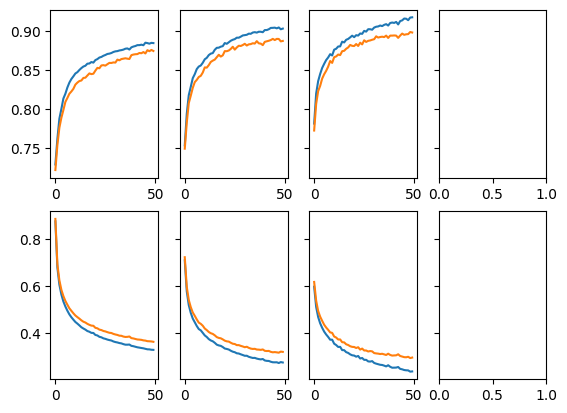

In [ ]:
fig, ax = plt.subplots(ncols=4, nrows=2, sharey="row")
for i, nf in enumerate([32, 64, 128]):
    # recreate model to reinitialize weights    # recreate model to reinitialize weights
    m = nn.Sequential(
        nn.Conv2d(1, nf, 3), nn.ReLU(),
        nn.Conv2d(nf, nf, 3), nn.ReLU(),
        nn.Flatten(),
        nn.Linear(nf*24*24, 10),
    )
    hist = fit_w_history(m, epochs=50, learning_rate=learning_rate)
    ax[0,i].plot(hist['accuracy'], label="accuracy")
    ax[0,i].plot(hist['val_accuracy'], label="val_accuracy")
    ax[1,i].plot(hist['loss'], label="loss")
    ax[1,i].plot(hist['val_loss'], label="val_loss")
#fig.legend()


### debugging: intepreting predictions

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [ ]:
# analyze errors

In [ ]:
with torch.no_grad():
    y_pred = m6(X_test.to(device)).cpu()
    y_true = y_test

In [ ]:
print(y_pred[:10])
print(y_test[:10])

tensor([[ -9.9690, -13.5224,  -9.5068, -11.1663, -10.1339,  -0.0794,  -7.1231,
           0.7181,  -3.0846,   5.4311],
        [ -4.9279, -21.4991,   1.6976, -16.6028,  -3.5289, -23.3248,  -4.5317,
         -37.5128, -14.8135, -24.8970],
        [ -6.5632,   7.0993, -14.5707,  -6.7467,  -9.9168, -12.5875, -13.7704,
         -20.8805, -10.8789, -17.5586],
        [ -8.3793,  10.0165, -13.0467,  -4.5113,  -5.6263, -12.8733, -12.5837,
         -18.3759, -12.0613, -12.2392],
        [ -0.2094, -10.1942,  -2.3878,  -4.5195,  -2.7574, -11.4040,   0.6695,
         -18.7460,  -7.5417, -10.3546],
        [ -3.8954,   5.7955, -10.1227,  -5.7794, -11.0665, -10.9215, -10.0870,
         -22.0234,  -8.1251, -17.5949],
        [ -5.7250, -11.2489,  -2.1158, -10.1286,   2.0162, -12.7699,  -2.4141,
         -29.7334, -10.3813, -20.4757],
        [ -9.1315, -15.6030,  -5.5629,  -8.0579,  -3.7908, -15.7212,   0.4324,
         -27.8193,  -8.9645, -19.2738],
        [ -6.0640, -12.8495,  -9.7611,  -8.4552,

In [ ]:
label_list = [labels[k] for k in sorted(labels.keys())]
label_list

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
y_pred = np.argmax(y_pred, axis=1)

In [ ]:
print(classification_report(y_true, y_pred, target_names=label_list))

              precision    recall  f1-score   support

 T-shirt/top       0.84      0.85      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.84      0.82      0.83      1000
       Dress       0.86      0.94      0.90      1000
        Coat       0.86      0.79      0.83      1000
      Sandal       0.97      0.98      0.97      1000
       Shirt       0.71      0.70      0.71      1000
     Sneaker       0.95      0.96      0.96      1000
         Bag       0.96      0.98      0.97      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.90     10000
   macro avg       0.89      0.90      0.89     10000
weighted avg       0.89      0.90      0.89     10000



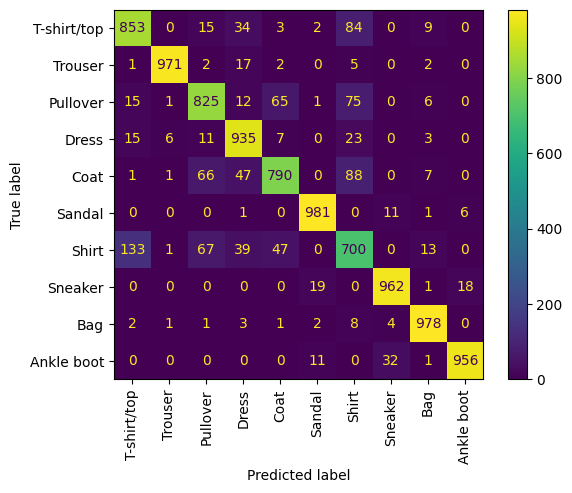

In [ ]:
disp = ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                                               display_labels=label_list,
                                               xticks_rotation="vertical")

In [ ]:
# shirt vs t-shirt problem
idx = np.flatnonzero((y_true==0) & (y_pred==6)) # t-shirt predicted as shirt
idx

array([ 452,  930,  937,  965, 1005, 1124, 1139, 1231, 1249, 1285, 1305,
       1572, 1586, 1686, 1731, 1861, 1867, 2218, 2506, 2571, 2653, 2730,
       2909, 3038, 3074, 3283, 3342, 3451, 3540, 3953, 4067, 4213, 4224,
       4381, 4460, 4917, 4924, 4965, 5032, 5119, 5144, 5297, 5307, 5435,
       5601, 5659, 5672, 5718, 5939, 5966, 5968, 6094, 6191, 6240, 6293,
       6654, 6679, 6926, 7059, 7599, 7831, 7883, 8007, 8031, 8059, 8348,
       8425, 8454, 8717, 8725, 8763, 8832, 8834, 9061, 9074, 9114, 9253,
       9349, 9398, 9571, 9662, 9719, 9748, 9981])

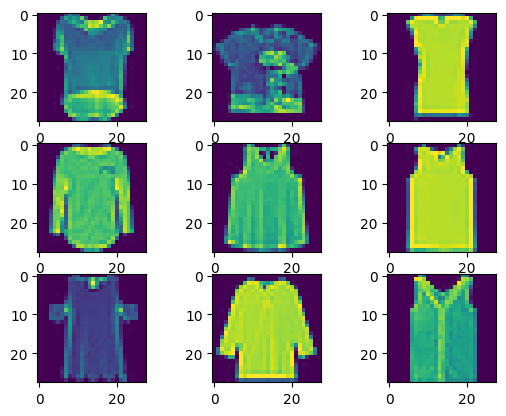

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=3)
for i, a in enumerate(ax.ravel()):
    a.imshow(X_test[idx[i]].numpy().transpose(1,2,0))

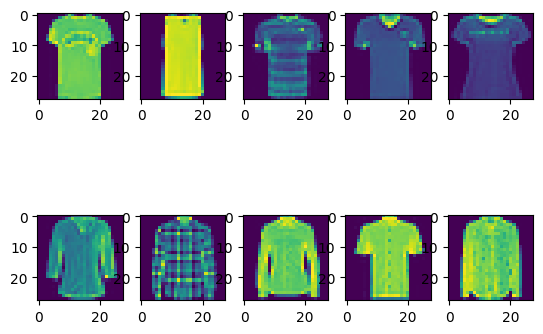

In [ ]:
# plot t-shirts and shirts
idx_t_shirt = np.flatnonzero(y_true==0)
idx_shirt = np.flatnonzero(y_true==6)
fig, ax = plt.subplots(nrows=2, ncols=5)
for i in range(5):
    a = ax[0,i]
    a.imshow(X_test[idx_t_shirt[i]].numpy().transpose(1,2,0))
    a = ax[1,i]
    a.imshow(X_test[idx_shirt[i]].numpy().transpose(1,2,0))

In [ ]:
# How to solve?
# 1. add more training examples from misclassified classes
# 2. use image augmentation

# Grad CAM

In [ ]:
# use padding same to avoid problems matching heatmap to image
mg = nn.Sequential(nn.Conv2d(1, 16, 3, padding="same"), nn.ReLU(),
                   nn.Conv2d(16, 16, 3, padding="same"), nn.ReLU(),
                   nn.Flatten(),
                   nn.Linear(16*28*28, 64), nn.ReLU(),
                   nn.Linear(64, 10),
)
fit(mg)

  0%|          | 0/469 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Accuracy at epoch 0 : 0.8701


  0%|          | 0/469 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

  0%|          | 0/79 [00:00<?, ?it/s]

Accuracy at epoch 3 : 0.8984


  0%|          | 0/469 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Accuracy at epoch 4 : 0.8995


#### add hooks to catch layer outputs and gradients

In [ ]:
# use classes as a hooks for elegance
# (avoid global variables)

class BackwardHook:
    """Catch output gradient of a layer."""
    def __init__(self, verbose=0):
        self.verbose = verbose
        self.grad = None
    def __call__(self, module, grad_input, grad_output):
        if self.verbose > 0:
            print("Enter backward hook")
        # grad_output is a tuple
        self.grad = grad_output[0].detach().clone()
        if self.verbose > 0:
            print("Grad shape", self.grad.shape)

In [ ]:
class ForwardHook:
    """Catch output of a layer."""
    def __init__(self, verbose=0):
        self.verbose = verbose
        self.output = None
    def __call__(self, module, args, output):
        if self.verbose > 0:
            print("Enter forward hook")
        self.output = output.detach().clone()
        if self.verbose > 0:
            print("Output shape", self.output.shape)

In [ ]:
layers = list(mg.children())
conv_output = layers[3]  # output of last convolutional layer
print(conv_output)
fh = ForwardHook(verbose=0)
fh_handle = conv_output.register_forward_hook(fh)
bh = BackwardHook(verbose=0)
bh_handle = conv_output.register_full_backward_hook(bh)

ReLU()


tensor([[-5.0300, -8.2831, -6.3881, -8.6651, -6.6413,  1.9688, -6.0867,  4.3657,
         -2.2699,  8.9043]], device='cuda:0', grad_fn=<AddmmBackward0>)
torch.Size([1, 28, 28])
tensor([[  3.5926, -15.7740,   9.3763,  -7.2851,   2.0451,  -1.9108,   1.6615,
         -10.7789,  -8.9527,  -9.6782]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
torch.Size([1, 28, 28])
tensor([[ 6.5978, -4.5399,  0.4540, -3.1290, -6.1353, -5.1139,  7.0151, -5.5220,
         -1.0267, -5.3421]], device='cuda:0', grad_fn=<AddmmBackward0>)
torch.Size([1, 28, 28])


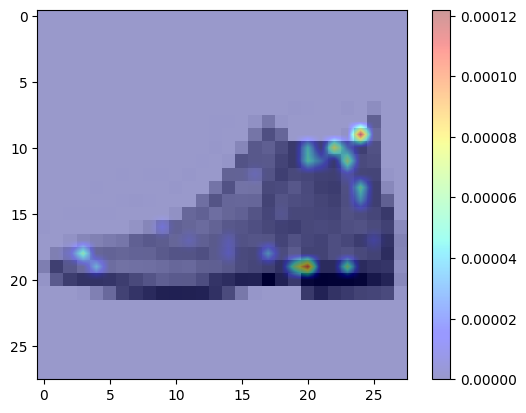

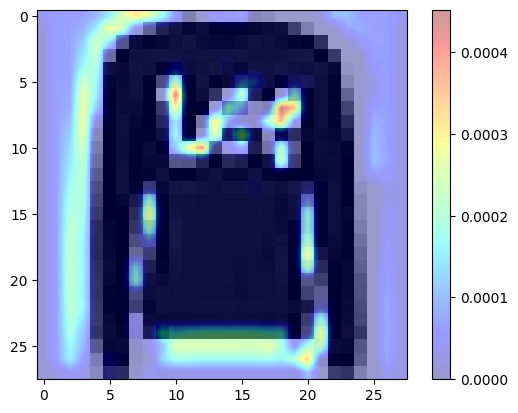

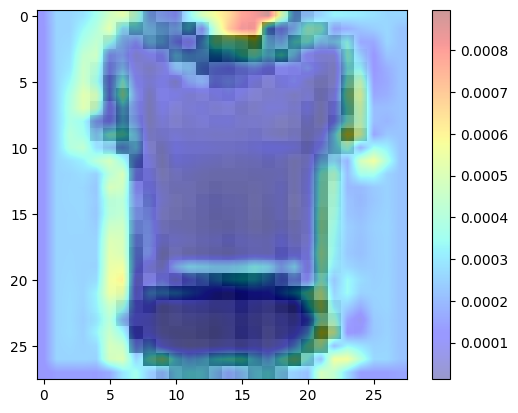

In [ ]:
for i in [0, 1, 452]:
    # compute the gradient and conv outputs
    y = mg(X_test[i:i+1].to(device))
    print(y)
    yi = y.argmax().item()
    y[0,yi].backward()


    # got outputs and gradients of the final conv layer
    #print(fh.output)
    #print(bh.grad)

    # weights for conv filters
    # computed based on averaged (pooled) gradients
    alpha = bh.grad.mean(axis=(2,3)) # average over pixels (not filters/channels)
    A = fh.output # activations

    # sum of conv filters weighted by alpha
    # reshape alpha to match shape of activations A
    alpha_r = alpha.reshape(alpha.shape[0], alpha.shape[1], 1,1)
    heatmap = F.relu((A * alpha_r).mean(axis=1))
    # ReLU is applied to cut negative influence on other classes
    print(heatmap.shape)

    # plot heatmap
    plt.figure()
    plt.imshow(X_test[i].numpy().transpose(1,2,0), cmap="Greys")
    plt.imshow(heatmap[0,:,:].cpu(), interpolation="bilinear", alpha=0.4, cmap="jet")
    plt.colorbar()

In [ ]:
fh_handle.remove()
bh_handle.remove()

In [ ]:
# add augmentation

In [ ]:
# use padding same to avoid problems matching heatmap to image
mg = nn.Sequential(TransformBlock(),
                   nn.Conv2d(1, 16, 3, padding="same"), nn.ReLU(),
                   nn.Conv2d(16, 16, 3, padding="same"), nn.ReLU(),
                   nn.Flatten(),
                   nn.Linear(16*28*28, 64), nn.ReLU(),
                   nn.Linear(64, 10),
)
fit(mg)

  0%|          | 0/469 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Accuracy at epoch 0 : 0.756


  0%|          | 0/469 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

  0%|          | 0/79 [00:00<?, ?it/s]

Accuracy at epoch 3 : 0.8109


  0%|          | 0/469 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Accuracy at epoch 4 : 0.8101


In [ ]:
layers = list(mg.children())
conv_output = layers[4]  # output of last convolutional layer
print(conv_output)
fh = ForwardHook(verbose=0)
fh_handle = conv_output.register_forward_hook(fh)
bh = BackwardHook(verbose=0)
bh_handle = conv_output.register_full_backward_hook(bh)

ReLU()


tensor([[ -7.2751, -15.7810, -10.9152,  -7.8485, -14.4724,   4.8359,  -5.9879,
          12.9927,  -3.1339,  13.0617]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
torch.Size([1, 28, 28])
tensor([[  1.3828, -11.3116,  11.5975,  -4.7270,   3.4483, -10.3831,   3.0696,
         -22.5026,  -1.3307,  -8.8443]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
torch.Size([1, 28, 28])
tensor([[  8.6699,  -2.5336,   3.9863,   0.8341,  -1.6005, -10.5365,   7.0839,
         -17.4003,  -4.6352,  -6.4207]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
torch.Size([1, 28, 28])


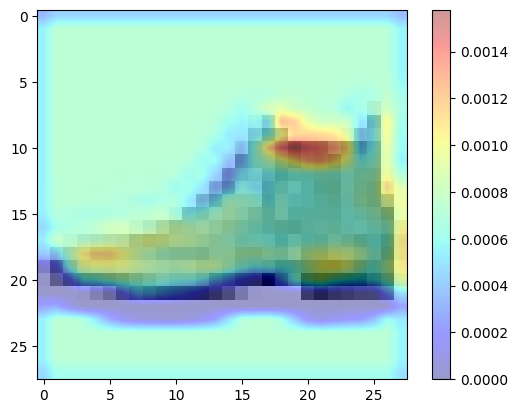

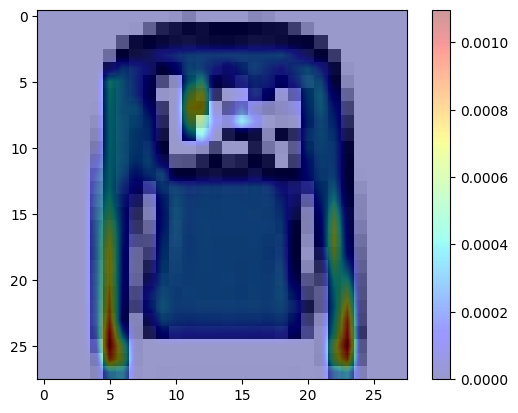

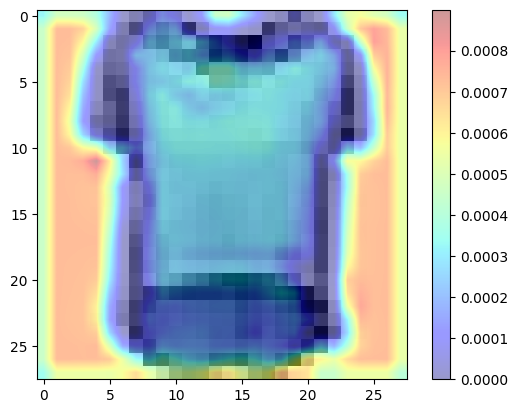

In [ ]:
for i in [0, 1, 452]:
    # compute the gradient and conv outputs
    y = mg(X_test[i:i+1].to(device))
    print(y)
    yi = y.argmax().item()
    y[0,yi].backward()


    # got outputs and gradients of the final conv layer
    #print(fh.output)
    #print(bh.grad)

    # weights for conv filters
    # computed based on averaged (pooled) gradients
    alpha = bh.grad.mean(axis=(2,3)) # average over pixels (not filters/channels)
    A = fh.output # activations

    # sum of conv filters weighted by alpha
    # reshape alpha to match shape of activations A
    alpha_r = alpha.reshape(alpha.shape[0], alpha.shape[1], 1,1)
    heatmap = F.relu((A * alpha_r).mean(axis=1))
    # ReLU is applied to cut negative influence on other classes
    print(heatmap.shape)

    # plot heatmap
    plt.figure()
    plt.imshow(X_test[i].numpy().transpose(1,2,0), cmap="Greys")
    plt.imshow(heatmap[0,:,:].cpu(), interpolation="bilinear", alpha=0.4, cmap="jet")
    plt.colorbar()